# 24 -- Task-generalisation check: does the model learn behaviour or task fingerprints?

**The worry (from nb11's decision-layer work)**: nb11 confirmed a related but
NARROWER risk -- raw decision-event COUNTS can separate ~44% of participant
pairs with zero behavioural signal (median separation score 0.0, share
above 0.5 = 44.4%). That's already mitigated: raw counts are excluded from
the behavioural feature set entirely (`count_`/`n_`/`support_` exclusion
rules in `build_behavioural_dataset.py`).

This notebook tests a DIFFERENT, broader, and previously untested question:
do the LEGITIMATE behavioural features (dwell times, tap dynamics) differ
systematically by WHICH of the app's 26 tasks a window comes from, such
that a model could learn task-specific fingerprints through features that
look genuinely behavioural -- and would therefore fail to generalise to
unstructured, free-form smartphone use it has never seen organised this
way. That's the actual question "would this work on general smartphone
use" is asking, and nothing built so far answers it directly.

**Design -- one new model, one existing model, same test data**:
- **Model A** (trained here): a subset of the 26 tasks is entirely excluded
  from its TRAIN-role data. It never sees a single window from those tasks
  during training.
- **Model B** (already exists): `nb15`'s own trained tap model
  (`tap_model_seed42.pt`) -- saw all 26 tasks during training, otherwise
  identical architecture/hyperparameters.
- Both are scored on the IDENTICAL held-out-task probe windows. If Model A
  performs meaningfully worse than Model B on exactly the same test data,
  that isolates a genuine task-generalisation gap -- both models had
  similar total training volume, the only difference is whether those
  specific tasks were present in training at all.

**Scope, stated up front**: tap only (not replicated across all four
modalities, given this needs actual retraining rather than reusing frozen
models like every other notebook this session). Single-window (k=1)
scoring, not the trust-window accumulation used elsewhere -- the question
here is generalisation to unseen task structure, not evidence
accumulation over time, so k=1 keeps this focused and simple. One fixed
task-holdout split, not repeated across multiple random splits -- a
single draw is enough to answer "is there a real gap," not enough to
precisely quantify its size.

**Not yet executed** -- new code, genuinely different from anything else
built this session (actual retraining with a modified split, not reused
frozen models). Expect a first-run debugging pass.


In [1]:
from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

%config InlineBackend.close_figures = False
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
OUT_DIR = MOD_DIR.parent / 'task_generalisation'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

tap_path = find(str(MOD_DIR / 'tap_windows.parquet'), 'tap_windows.parquet')
splits_path = find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv')
df = pd.read_parquet(tap_path)
splits = pd.read_csv(splits_path)
df = df.merge(splits[['sessionId', 'role']], on='sessionId', how='inner').reset_index(drop=True)
print(f"tap windows: {df.shape}")
print(f"unique tasks: {df['taskIndex'].nunique()}")


tap windows: (3324, 110)
unique tasks: 26


## 1. Feature preparation (identical to nb15's, so results are comparable)

In [2]:
ID = {'sessionId','participantId','deviceFamily','window_index','window_start_s','window_end_s',
      'taskIndex','taskType','activeArea','task_pass','task_start_s','task_end_s','role'}

feats = [c for c in df.columns if c not in ID and pd.api.types.is_numeric_dtype(df[c])]
coverage = df[feats].notna().mean()
feats = coverage[coverage >= 0.5].index.tolist()
print(f"{len(feats)} features used")

train_df = df[df['role'] == 'train']
imputer = SimpleImputer(strategy='median').fit(train_df[feats])
scaler = StandardScaler().fit(imputer.transform(train_df[feats]))

def embed_input(sub):
    return scaler.transform(imputer.transform(sub[feats])).astype(np.float32)

X_all = embed_input(df)
y_all = df['participantId'].values
role_all = df['role'].values
task_all = df['taskIndex'].values
print(f"X_all: {X_all.shape}")


97 features used
X_all: (3324, 97)


## 2. Task holdout split

Fixed random seed, held out ~23% of tasks (6 of 26) -- entirely excluded
from Model A's training data below.


In [3]:
ALL_TASKS = sorted(df['taskIndex'].unique())
rng = np.random.default_rng(42)
HELDOUT_TASKS = set(rng.choice(ALL_TASKS, size=max(1, round(len(ALL_TASKS) * 0.23)), replace=False))
TRAIN_TASKS = set(ALL_TASKS) - HELDOUT_TASKS
print(f"{len(ALL_TASKS)} total tasks -> {len(TRAIN_TASKS)} kept for training, "
      f"{len(HELDOUT_TASKS)} held out entirely: {sorted(HELDOUT_TASKS)}")

# Modified role array: train-role windows on held-out tasks are relabelled
# so train_embedder's role=='train' mask (reused unchanged below) naturally
# excludes them -- no changes needed to the training function itself.
role_task_restricted = role_all.copy()
excluded_mask = (role_all == 'train') & np.isin(task_all, list(HELDOUT_TASKS))
role_task_restricted[excluded_mask] = 'train_excluded_heldout_task'
print(f"\n{excluded_mask.sum()} train-role windows excluded from Model A's training "
      f"({(role_all=='train').sum()} -> {(role_task_restricted=='train').sum()} remaining)")

train_task_counts = df[df['role']=='train'].groupby('participantId')['taskIndex'].apply(
    lambda s: (~s.isin(HELDOUT_TASKS)).sum())
print(f"\nRemaining train windows per identity after task exclusion (min={train_task_counts.min()}):")
print(train_task_counts.to_string())


26 total tasks -> 20 kept for training, 6 held out entirely: [1.0, 10.0, 15.0, 17.0, 22.0, 24.0]

440 train-role windows excluded from Model A's training (2502 -> 2062 remaining)

Remaining train windows per identity after task exclusion (min=17):
participantId
p3M6E7Z    100
p3YDMHG    328
p95MPVX    414
pA6XL23     63
pAFQRTM     79
pCTJ44P     29
pCURDWC     17
pEAB9GS     27
pEZVKTS     48
pG2C8BC     21
pG5G4MS    205
pH3S4X4    387
pNDG8LJ    163
pUNKH7L     35
pW49U3Q     32
pWJGKPK     64
pZMC82M     50


## 3. Train Model A (task-restricted) -- architecture/hyperparameters identical to nb15

In [4]:
IDENTITIES_PER_BATCH = 2
WINDOWS_PER_IDENTITY = 4
MARGIN = 0.20
EMBED_DIM = 32
EPOCHS = 40
LR = 1e-4
WEIGHT_DECAY = 1e-4
MAX_BATCHES_PER_EPOCH = 150

class BalancedIdentityBatchSampler(torch.utils.data.Sampler):
    def __init__(self, labels, identities_per_batch, windows_per_identity,
                 max_batches=MAX_BATCHES_PER_EPOCH, seed=0):
        self.by_identity = {pid: np.where(labels == pid)[0] for pid in np.unique(labels)}
        self.eligible = [pid for pid, idx in self.by_identity.items()
                          if len(idx) >= windows_per_identity]
        self.k, self.m = identities_per_batch, windows_per_identity
        self.rng = np.random.default_rng(seed)
        natural = max(1, sum(len(v) for v in self.by_identity.values()) // (self.k * self.m))
        self.n_batches = min(natural, max_batches)

    def __iter__(self):
        for _ in range(self.n_batches):
            pids = self.rng.choice(self.eligible, size=self.k, replace=False)
            batch = []
            for pid in pids:
                idx = self.by_identity[pid]
                chosen = self.rng.choice(idx, size=self.m, replace=len(idx) < self.m)
                batch.extend(chosen.tolist())
            yield batch

    def __len__(self):
        return self.n_batches


class Embedder(nn.Module):
    def __init__(self, in_dim, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        return nn.functional.normalize(self.net(x), p=2, dim=1)


def batch_all_triplet_loss(embeddings, labels, margin=MARGIN):
    dist = torch.cdist(embeddings, embeddings, p=2)
    labels = labels.unsqueeze(0)
    same = (labels == labels.T)
    eye = torch.eye(len(labels[0]), dtype=torch.bool, device=embeddings.device)
    pos_mask, diff = same & ~eye, ~same

    losses = []
    for a in range(len(embeddings)):
        pos_d, neg_d = dist[a][pos_mask[a]], dist[a][diff[a]]
        if len(pos_d) == 0 or len(neg_d) == 0:
            continue
        l = torch.clamp(pos_d.unsqueeze(1) - neg_d.unsqueeze(0) + margin, min=0)
        losses.append(l.flatten())
    if not losses:
        return torch.tensor(0.0, requires_grad=True), 0.0
    all_losses = torch.cat(losses)
    active = all_losses[all_losses > 0]
    return all_losses.mean(), (active.numel() / max(all_losses.numel(), 1))


def train_embedder(X, y, role, seed=0, epochs=EPOCHS, verbose=True):
    torch.manual_seed(seed)
    train_mask = role == 'train'
    X_train, y_train = X[train_mask], y[train_mask]
    model = Embedder(X.shape[1], EMBED_DIM)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sampler = BalancedIdentityBatchSampler(y_train, IDENTITIES_PER_BATCH, WINDOWS_PER_IDENTITY, seed=seed)
    history = {'epoch': [], 'loss': [], 'active_frac': []}
    for epoch in range(epochs):
        model.train()
        epoch_losses, epoch_actives = [], []
        for batch_idx in sampler:
            xb = torch.tensor(X_train[batch_idx])
            yb = torch.tensor(pd.factorize(y_train[batch_idx])[0])
            opt.zero_grad()
            emb = model(xb)
            loss, active_frac = batch_all_triplet_loss(emb, yb)
            loss.backward(); opt.step()
            epoch_losses.append(loss.item()); epoch_actives.append(active_frac)
        history['epoch'].append(epoch)
        history['loss'].append(np.mean(epoch_losses))
        history['active_frac'].append(np.mean(epoch_actives))
        if verbose and (epoch % 10 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:2d}  loss={history['loss'][-1]:.4f}  active_frac={history['active_frac'][-1]:.3f}")
    return model, pd.DataFrame(history)

print("Training Model A (task-restricted)...")
model_a, history_a = train_embedder(X_all, y_all, role_task_restricted, seed=42)
print("Model A training complete.")


Training Model A (task-restricted)...
  epoch  0  loss=0.1458  active_frac=0.664
  epoch 10  loss=0.0676  active_frac=0.341
  epoch 20  loss=0.0481  active_frac=0.246
  epoch 30  loss=0.0301  active_frac=0.174
  epoch 39  loss=0.0295  active_frac=0.167
Model A training complete.


## 4. Load Model B (nb15's existing, unrestricted tap model)

Uses Model B's OWN saved `feature_names` for embedding rather than
assuming this notebook's freshly-built `feats` list matches exactly --
protects against a silent mismatch if anything about the data changed
since nb15 was last run.


In [5]:
tap_embedder_dir = Path(find(str(MOD_DIR.parent / 'tap_embedder'), 'tap_embedder'))
ckpt_b = torch.load(tap_embedder_dir / 'tap_model_seed42.pt', weights_only=False)
feats_b = list(ckpt_b['feature_names'])
model_b = Embedder(len(feats_b), ckpt_b['embed_dim'])
model_b.load_state_dict(ckpt_b['state_dict'])
model_b.eval()

prep_b = np.load(tap_embedder_dir / 'tap_preprocessing.npz', allow_pickle=True)
assert list(prep_b['feature_names']) == feats_b, "Model B: preprocessing/model feature order mismatch"

def embed_input_b(sub):
    X = sub[feats_b].to_numpy(dtype=np.float64)
    nan_mask = np.isnan(X)
    if nan_mask.any():
        X = np.where(nan_mask, prep_b['impute_values'], X)
    X = (X - prep_b['scale_mean']) / prep_b['scale_scale']
    return X.astype(np.float32)

X_all_b = embed_input_b(df)
print(f"Model B loaded: {len(feats_b)} features (vs Model A's {len(feats)}) -- "
      f"{'MATCH' if feats_b == feats else 'DIFFERENT feature set, handled via separate preprocessing'}")


Model B loaded: 97 features (vs Model A's 97) -- MATCH


## 5. Score both models, single-window (k=1), split by task group

In [6]:
def score_single_window(model, X, y, role_arr, task_arr):
    model.eval()
    with torch.no_grad():
        E = model(torch.tensor(X, dtype=torch.float32)).numpy()
    enrol_mask, probe_mask = role_arr == 'enrol', role_arr == 'probe'
    refs = {pid: E[enrol_mask & (y == pid)].mean(axis=0) for pid in np.unique(y[enrol_mask])}
    rows = []
    for i in np.where(probe_mask)[0]:
        pid = y[i]
        for cand, ref in refs.items():
            rows.append({'pid': pid, 'cand': cand, 'genuine': int(cand == pid),
                         'dist': float(np.linalg.norm(E[i] - ref)),
                         'row_id': i, 'task': task_arr[i]})
    scored = pd.DataFrame(rows)
    scored['z'] = scored.groupby('row_id')['dist'].transform(
        lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
    return scored, refs

def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    return {'auc': float(auc), 'eer': float((fpr[idx] + frr[idx]) / 2)}

scored_a, refs_a = score_single_window(model_a, X_all, y_all, role_all, task_all)
scored_b, refs_b = score_single_window(model_b, X_all_b, y_all, role_all, task_all)

results = []
for label, scored in [('Model A (task-restricted)', scored_a), ('Model B (unrestricted, nb15)', scored_b)]:
    for group_name, group_tasks in [('seen_tasks', TRAIN_TASKS), ('heldout_tasks', HELDOUT_TASKS)]:
        sub = scored[scored['task'].isin(group_tasks)]
        m = compute_metrics(sub['genuine'], -sub['z'])
        results.append({'model': label, 'task_group': group_name, 'n_probe_windows': sub['row_id'].nunique(),
                         **m})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))


                       model    task_group  n_probe_windows   auc   eer
   Model A (task-restricted)    seen_tasks              278 0.824 0.227
   Model A (task-restricted) heldout_tasks               64 0.788 0.259
Model B (unrestricted, nb15)    seen_tasks              278 0.837 0.216
Model B (unrestricted, nb15) heldout_tasks               64 0.817 0.239


## 6. Interpretation

The key comparison is Model A vs Model B, BOTH on `heldout_tasks` -- the
identical test windows, scored by a model that never trained on that task
type (A) versus one that did (B). A meaningfully lower AUC for Model A
here, with both models performing similarly on `seen_tasks`, isolates a
real task-generalisation gap. If Model A's `heldout_tasks` AUC is close to
Model B's, that's evidence the model is learning genuinely person-general
behaviour rather than task-specific fingerprints.


model          Model A (task-restricted)  Model B (unrestricted, nb15)
task_group                                                            
heldout_tasks                      0.788                         0.817
seen_tasks                         0.824                         0.837

Model B minus Model A, on IDENTICAL heldout_tasks probe windows: +0.029
-> Small gap: some task-specific signal may exist, but the effect is modest relative to
   the small-N noise already established throughout this project's evaluation work.


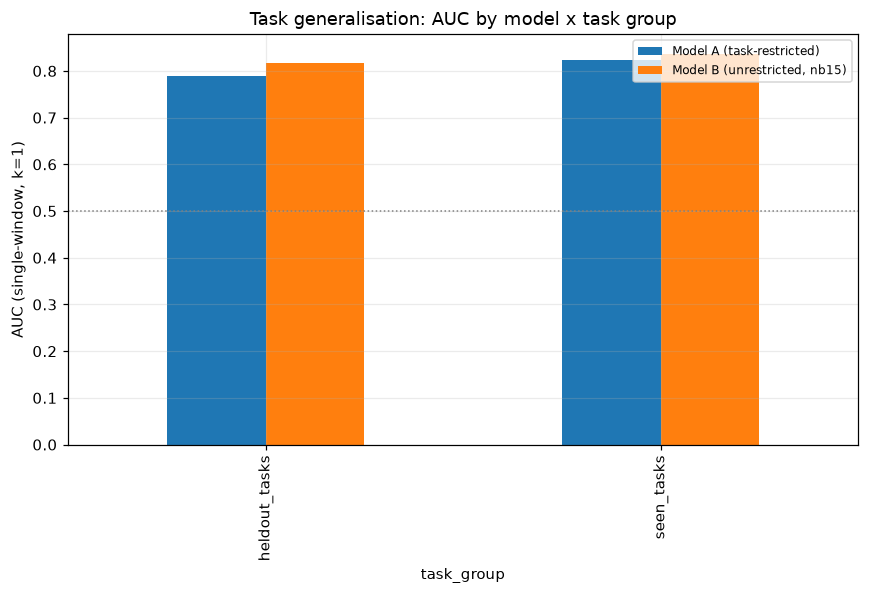

In [7]:
pivot = results_df.pivot(index='task_group', columns='model', values='auc')
print(pivot.round(3).to_string())
print()

gap = pivot.loc['heldout_tasks', 'Model B (unrestricted, nb15)'] - pivot.loc['heldout_tasks', 'Model A (task-restricted)']
print(f"Model B minus Model A, on IDENTICAL heldout_tasks probe windows: {gap:+.3f}")
if gap > 0.05:
    print("-> Meaningful gap: some task-specific fingerprinting is plausible. Model A's degradation")
    print("   on tasks it never trained on, relative to a model that did, is not explained by less")
    print("   total training data alone -- both models were trained on similar total volume.")
elif gap > 0.02:
    print("-> Small gap: some task-specific signal may exist, but the effect is modest relative to")
    print("   the small-N noise already established throughout this project's evaluation work.")
else:
    print("-> No meaningful gap: consistent with the model learning genuinely person-general")
    print("   behaviour rather than task-specific fingerprints.")

fig, ax = plt.subplots(figsize=(8, 5.5))
pivot.plot(kind='bar', ax=ax)
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_ylabel('AUC (single-window, k=1)')
ax.set_title('Task generalisation: AUC by model x task group')
ax.legend(fontsize=8)
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_task_generalisation.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
import json as _json
from datetime import datetime, timezone

results_df.to_csv(OUT_DIR / 'task_generalisation_results.csv', index=False)
manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'heldout_tasks': sorted(int(t) for t in HELDOUT_TASKS),
    'train_tasks': sorted(int(t) for t in TRAIN_TASKS),
    'results': results_df.to_dict('records'),
    'model_b_minus_model_a_heldout_gap': float(gap),
    'scope_note': 'tap modality only, single fixed task-holdout split, single-window (k=1) scoring',
}
with open(OUT_DIR / 'task_generalisation_manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)
print(f"Wrote outputs to {OUT_DIR.resolve()}")


Wrote outputs to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/task_generalisation
